In [75]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Event selection.
OPENING_TRANSITION = "closed_to_open"
EVENT_ANCHOR_DATE_COL = "window_end_date"
USE_OPENING_EVAL_WINDOW = False
MIN_FOLLOWING_OPEN_DAYS = 10  # e.g. 14, 30, or None to only use the flag above

# Model / driver configuration.
MODEL_NAME = "pymc_all_closed"
MODEL_FLOW_COL = "flow_window"
RAW_FLOW_COL = "flow_sum_rolling_7d"
FIXED_COLS = ["wave_window", "month_sin", "month_cos"]
TARGET_OPEN_PROB = 0.70

# Raw-flow inversion.
# Keep this as ("region",) first. If you want year-specific empirical inversions,
# try ("region", "year") after checking sample sizes.
RAW_LOOKUP_GROUP_COLS = ("region",)  # "water_year"

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

In [3]:
def expit(x):
    return 1 / (1 + np.exp(-x))


def logit(p):
    p = np.asarray(p)
    return np.log(p / (1 - p))


def require_columns(df, required, df_name):
    missing = sorted(set(required) - set(df.columns))
    if missing:
        raise KeyError(f"{df_name} is missing required columns: {missing}")


def truthy_series(s):
    """Handle booleans, 0/1, and string-ish booleans."""
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False)
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float).ne(0)

    normalized = s.astype("string").str.strip().str.lower()
    return normalized.isin(["true", "t", "yes", "y", "1"])


def prepare_events(events_df, anchor_date_col=EVENT_ANCHOR_DATE_COL):
    required = [
        "region",
        "window_start_date",
        "window_end_date",
        "window_start_state",
        "window_end_state",
        "transition",
    ]
    require_columns(events_df, required, "events_df")

    events = events_df.copy()
    events["window_start_date"] = pd.to_datetime(events["window_start_date"])
    events["window_end_date"] = pd.to_datetime(events["window_end_date"])
    events["event_date"] = pd.to_datetime(events[anchor_date_col])
    events["event_water_year"] = events["event_date"].dt.year + events["event_date"].dt.month.ge(
        10
    ).astype(int)
    events["window_days"] = (events["window_end_date"] - events["window_start_date"]).dt.days

    return events.sort_values(["region", "window_start_date", "window_end_date"]).reset_index(
        drop=True
    )


def add_following_open_spell(events):
    """For each closed_to_open event, estimate how long the next open spell lasts."""
    out = events.copy()
    out["following_open_until_date"] = pd.NaT
    out["following_open_days"] = np.nan
    out["following_open_is_censored"] = False

    for _, g in out.groupby("region", sort=False):
        g = g.sort_values(["window_start_date", "window_end_date"])
        region_end = g["window_end_date"].max()
        closing_events = g[g["window_end_state"].eq("closed")]

        opening_events = g[
            (g["transition"].eq(OPENING_TRANSITION))
            & (g["window_start_date"].dt.month.isin([10, 11, 12, 1, 2, 3, 4]))
        ]

        for idx, row in opening_events.iterrows():
            opening_date = row["window_end_date"]
            later_closings = closing_events[closing_events["window_start_date"].ge(opening_date)]

            if later_closings.empty:
                open_until = region_end
                censored = True
            else:
                open_until = later_closings.iloc[0]["window_end_date"]
                censored = False

            out.loc[idx, "following_open_until_date"] = open_until
            out.loc[idx, "following_open_days"] = (open_until - opening_date).days
            out.loc[idx, "following_open_is_censored"] = censored

    return out


def select_first_extended_openings(events):
    mask = events["transition"].eq(OPENING_TRANSITION)

    if USE_OPENING_EVAL_WINDOW and "opening_eval_window" in events.columns:
        mask &= truthy_series(events["opening_eval_window"])

    if MIN_FOLLOWING_OPEN_DAYS is not None:
        mask &= events["following_open_days"].ge(MIN_FOLLOWING_OPEN_DAYS)

    openings = events.loc[mask].copy()

    first_openings = (
        openings.sort_values(["region", "event_water_year", "event_date"])
        .groupby(["region", "event_water_year"], as_index=False, sort=False)
        .head(1)
        .reset_index(drop=True)
    )

    return openings, first_openings


def add_missed_opening_and_closing_events(
    events_df,
    min_gap_days=1,
    require_prev_stable=False,
):
    events = events_df.copy()

    for col in ["window_start_date", "window_end_date"]:
        events[col] = pd.to_datetime(events[col])

    events = events.sort_values(["region", "window_start_date", "window_end_date"]).reset_index(
        drop=True
    )

    synthetic_rows = []

    for region, g in events.groupby("region", sort=False):
        g = g.sort_values(["window_start_date", "window_end_date"])

        pairs = zip(
            g.iloc[:-1].to_dict("records"),
            g.iloc[1:].to_dict("records"),
        )

        for prev, nxt in pairs:
            gap_days = (nxt["window_start_date"] - prev["window_end_date"]).days
            if gap_days < min_gap_days:
                continue

            prev_end_state = prev["window_end_state"]
            next_start_state = nxt["window_start_state"]

            missed_opening = prev_end_state == "closed" and next_start_state == "open"

            missed_closing = prev_end_state == "open" and next_start_state == "closed"

            if require_prev_stable:
                missed_opening &= prev["transition"] == "closed_to_closed"
                missed_closing &= prev["transition"] == "open_to_open"

            if not (missed_opening or missed_closing):
                continue

            start_p_open = prev.get("window_end_p_open", np.nan)
            end_p_open = nxt.get("window_start_p_open", np.nan)
            p_open_change = end_p_open - start_p_open

            row = {col: np.nan for col in events.columns}

            row.update(
                {
                    "region": region,
                    "window_start_date": prev["window_end_date"],
                    "window_end_date": nxt["window_start_date"],
                    "obs_gap_days": gap_days,
                    "window_start_state": prev_end_state,
                    "window_end_state": next_start_state,
                    "window_start_p_open": start_p_open,
                    "window_end_p_open": end_p_open,
                    "previous_transition": prev["transition"],
                    "next_transition": nxt["transition"],
                    "synthetic_event": True,
                    "synthetic_gap_days": gap_days,
                }
            )

            if missed_opening:
                row.update(
                    {
                        "transition": "closed_to_open",
                        "opening_eval_window": True,
                        "opening_change": p_open_change,
                        "closing_eval_window": False,
                        "closing_change": np.nan,
                        "synthetic_event_reason": "missed_opening_between_closed_and_open",
                        "opening_date_is_first_known_open_date": True,
                        "closing_date_is_first_known_closed_date": False,
                    }
                )

            if missed_closing:
                row.update(
                    {
                        "transition": "open_to_closed",
                        "opening_eval_window": False,
                        "opening_change": np.nan,
                        "closing_eval_window": True,
                        "closing_change": p_open_change,
                        "synthetic_event_reason": "missed_closing_between_open_and_closed",
                        "opening_date_is_first_known_open_date": False,
                        "closing_date_is_first_known_closed_date": True,
                    }
                )

            synthetic_rows.append(row)

    out = events.copy()

    synthetic_cols = {
        "synthetic_event": False,
        "synthetic_event_reason": np.nan,
        "synthetic_gap_days": np.nan,
        "previous_transition": np.nan,
        "next_transition": np.nan,
        "opening_date_is_first_known_open_date": False,
        "closing_date_is_first_known_closed_date": False,
    }

    for col, default in synthetic_cols.items():
        if col not in out.columns:
            out[col] = default
        else:
            out[col] = out[col].fillna(default)

    if synthetic_rows:
        out = pd.concat([out, pd.DataFrame(synthetic_rows)], ignore_index=True)

    out = out.sort_values(
        ["region", "window_start_date", "window_end_date", "synthetic_event"]
    ).reset_index(drop=True)

    out["event_date"] = out["window_end_date"]
    out["event_water_year"] = out["event_date"].dt.year + out["event_date"].dt.month.ge(10).astype(
        int
    )

    return out


def find_preseason_openings_before_dominant(
    events,
    first_openings,
    opening_transition=OPENING_TRANSITION,
):
    opening_candidates = events.loc[events["transition"].eq(opening_transition)].copy()

    dominant = first_openings[
        [
            "region",
            "event_water_year",
            "event_date",
            "following_open_days",
            "synthetic_event",
        ]
    ].rename(
        columns={
            "event_date": "dominant_opening_date",
            "following_open_days": "dominant_following_open_days",
            "synthetic_event": "dominant_synthetic_event",
        }
    )

    pre = opening_candidates.merge(
        dominant,
        on=["region", "event_water_year"],
        how="inner",
        validate="m:1",
    )

    pre = pre[pre["event_date"].lt(pre["dominant_opening_date"])].copy()

    pre["days_before_dominant_opening"] = (pre["dominant_opening_date"] - pre["event_date"]).dt.days

    pre["is_preseason_partial_opening"] = True

    return pre.sort_values(["region", "event_water_year", "event_date"]).reset_index(drop=True)

In [41]:
base = Path("/Users/kyledorman/data/results/estuary/train/20260305-095554/seasonal_drivers")
events_df = pd.read_parquet(base / "transition_event_windows.parquet")
events_df = events_df[events_df.region != 33].copy()
events = prepare_events(events_df)
events = add_missed_opening_and_closing_events(
    events,
    min_gap_days=1,
)
events = add_following_open_spell(events)
events = events[events.event_water_year.between(2019, 2025)].copy()
opening_events, first_openings = select_first_extended_openings(events)

print("All event transitions:")
display(events["transition"].value_counts(dropna=False))

print("Candidate extended opening events:")
display(opening_events["transition"].value_counts(dropna=False))

print("First extended opening per region/year:")
display(
    first_openings[
        [
            "region",
            "event_water_year",
            "event_date",
            "window_start_date",
            "window_end_date",
            "obs_gap_days",
            "window_start_state",
            "window_end_state",
            "window_start_p_open",
            "window_end_p_open",
            "opening_eval_window",
            "opening_change",
            "following_open_days",
            "following_open_is_censored",
        ]
    ].head(20)
)

print(
    {
        "regions_with_first_opening": first_openings["region"].nunique(),
        "region_year_first_openings": len(first_openings),
        "years": sorted(first_openings["event_water_year"].dropna().unique().tolist()),
    }
)

All event transitions:


transition
open_to_open        735
closed_to_closed    567
closed_to_open      357
open_to_closed      356
Name: count, dtype: int64

Candidate extended opening events:


transition
closed_to_open    152
Name: count, dtype: int64

First extended opening per region/year:


,region,event_water_year,event_date,window_start_date,window_end_date,obs_gap_days,window_start_state,window_end_state,window_start_p_open,window_end_p_open,opening_eval_window,opening_change,following_open_days,following_open_is_censored
0,14,2019,2018-12-08,2018-12-07,2018-12-08,1.0,closed,open,0.005178,0.999876,1,1.000000,895.0,False
1,14,2022,2021-12-16,2021-12-15,2021-12-16,1.0,closed,open,0.000262,0.999998,1,1.000000,147.0,False
2,14,2023,2023-01-17,2022-12-25,2023-01-17,23.0,closed,open,0.006294,0.999924,1,0.993630,911.0,False
3,15,2019,2019-01-26,2019-01-25,2019-01-26,1.0,closed,open,0.000004,0.999982,1,1.000000,1801.0,False
4,15,2024,2024-01-26,2024-01-19,2024-01-26,7.0,closed,open,0.000017,0.999810,1,1.000000,236.0,False
5,15,2025,2025-02-16,2025-02-08,2025-02-16,8.0,closed,open,0.000147,0.999868,1,0.999722,168.0,False
6,16,2019,2019-02-15,2019-02-12,2019-02-15,3.0,closed,open,0.000073,0.998734,1,1.000000,12.0,False
7,16,2023,2023-03-22,2023-03-03,2023-03-22,19.0,closed,open,0.208691,0.999978,1,0.791287,24.0,False
8,16,2024,2024-02-11,2024-02-03,2024-02-11,8.0,closed,open,0.000727,0.999833,1,0.999106,40.0,False
9,16,2025,2025-03-17,2025-03-15,2025-03-17,2.0,closed,open,0.287824,0.967146,1,1.000000,11.0,False


{'regions_with_first_opening': 17, 'region_year_first_openings': 98, 'years': [2019, 2020, 2021, 2022, 2023, 2024, 2025]}


In [42]:
preseason_openings = find_preseason_openings_before_dominant(
    events,
    first_openings,
)

display(
    preseason_openings[
        [
            "region",
            "event_water_year",
            "event_date",
            "dominant_opening_date",
            "days_before_dominant_opening",
            "window_start_date",
            "window_end_date",
            "obs_gap_days",
            "window_start_p_open",
            "window_end_p_open",
            "opening_change",
            "following_open_days",
            "dominant_following_open_days",
            "synthetic_event",
            "dominant_synthetic_event",
        ]
    ].head(50)
)

print(
    {
        "preseason_partial_openings": len(preseason_openings),
        "region_water_years_with_preseason_openings": (
            preseason_openings[["region", "event_water_year"]].drop_duplicates().shape[0]
        ),
    }
)

,region,event_water_year,event_date,dominant_opening_date,days_before_dominant_opening,window_start_date,window_end_date,obs_gap_days,window_start_p_open,window_end_p_open,opening_change,following_open_days,dominant_following_open_days,synthetic_event,dominant_synthetic_event
0,15,2025,2024-10-18,2025-02-16,121,2024-09-18,2024-10-18,30.0,0.271857,0.998401,0.726544,NaN,168.0,True,True
1,15,2025,2025-01-05,2025-02-16,42,2025-01-02,2025-01-05,3.0,0.287191,0.872056,1.000000,3.0,168.0,False,True
2,16,2023,2023-01-18,2023-03-22,63,2022-12-26,2023-01-18,23.0,0.000003,0.996797,0.996794,9.0,24.0,True,True
3,16,2023,2023-02-20,2023-03-22,30,2023-02-17,2023-02-20,3.0,0.000025,0.926586,1.000000,1.0,24.0,False,True
4,16,2025,2025-02-23,2025-03-17,22,2025-02-18,2025-02-23,5.0,0.000259,0.997651,1.000000,2.0,11.0,False,False
5,16,2025,2025-03-09,2025-03-17,8,2025-03-07,2025-03-09,2.0,0.102767,0.995019,1.000000,6.0,11.0,False,False
6,21,2021,2020-12-06,2020-12-29,23,2020-12-03,2020-12-06,3.0,0.000241,0.999932,1.000000,3.0,148.0,False,False
7,21,2021,2020-12-13,2020-12-29,16,2020-12-12,2020-12-13,1.0,0.000106,0.999964,1.000000,3.0,148.0,False,False
8,21,2021,2020-12-19,2020-12-29,10,2020-12-16,2020-12-19,3.0,0.095141,0.999428,1.000000,6.0,148.0,False,False
9,22,2019,2018-12-18,2019-01-10,23,2018-12-16,2018-12-18,2.0,0.000182,0.999988,1.000000,6.0,176.0,False,True


{'preseason_partial_openings': 60, 'region_water_years_with_preseason_openings': 38}


In [43]:
sim_all = pd.read_parquet("/Users/kyledorman/Desktop/sim_all.parquet")


def prepare_sim(sim_all):
    required = ["region", "date", MODEL_FLOW_COL, RAW_FLOW_COL, *FIXED_COLS]
    require_columns(sim_all, required, "sim_all")

    sim = sim_all.copy()
    sim["date"] = pd.to_datetime(sim["date"])

    if "model" in sim.columns and MODEL_NAME in set(sim["model"].dropna()):
        sim = sim[sim["model"].eq(MODEL_NAME)].copy()

    if "year" not in sim.columns:
        sim["year"] = sim["date"].dt.year

    return sim


def attach_max_flow_driver_rows(
    openings,
    sim,
    flow_col=RAW_FLOW_COL,
    event_start_col="window_start_date",
    event_end_col="window_end_date",
):
    driver_cols = [
        "region",
        "date",
        MODEL_FLOW_COL,
        RAW_FLOW_COL,
        *FIXED_COLS,
        "year",
        "water_year",
        "p_if_closed",
        "p_if_open",
        "p_open_sim",
        "prev_state",
        "prev_p_open",
        "confident_state_lag7",
    ]
    driver_cols = [col for col in driver_cols if col in sim.columns]

    x = openings.copy()
    x[event_start_col] = pd.to_datetime(x[event_start_col])
    x[event_end_col] = pd.to_datetime(x[event_end_col])

    sim_lookup = sim[driver_cols].copy()
    sim_lookup["date"] = pd.to_datetime(sim_lookup["date"])

    matched_rows = []

    for idx, row in x.iterrows():
        region = row["region"]
        start_date = row[event_start_col]
        end_date = row[event_end_col]

        candidates = sim_lookup[
            sim_lookup["region"].eq(region)
            & sim_lookup["date"].between(start_date, end_date, inclusive="both")
            & sim_lookup[flow_col].notna()
        ].copy()

        out_row = row.to_dict()

        if candidates.empty:
            for col in driver_cols:
                if col != "region":
                    out_row[col] = np.nan

            out_row["missing_driver_row"] = True
            out_row["driver_join_method"] = "max_flow_in_event_window"
            out_row["driver_window_start_date"] = start_date
            out_row["driver_window_end_date"] = end_date
            out_row["driver_window_n_days"] = 0
            out_row["driver_selected_flow_col"] = flow_col
            out_row["driver_selected_date"] = pd.NaT

        else:
            # If tied on max flow, take the earliest max-flow day.
            candidates = candidates.sort_values(
                [flow_col, "date"],
                ascending=[False, True],
            )
            best = candidates.iloc[0]

            for col in driver_cols:
                if col != "region":
                    out_row[col] = best[col]

            out_row["missing_driver_row"] = False
            out_row["driver_join_method"] = "max_flow_in_event_window"
            out_row["driver_window_start_date"] = start_date
            out_row["driver_window_end_date"] = end_date
            out_row["driver_window_n_days"] = len(candidates)
            out_row["driver_selected_flow_col"] = flow_col
            out_row["driver_selected_date"] = best["date"]

        matched_rows.append(out_row)

    return pd.DataFrame(matched_rows)


sim = prepare_sim(sim_all)

first_opening_drivers = attach_max_flow_driver_rows(
    first_openings,
    sim,
    flow_col=MODEL_FLOW_COL,  # or MODEL_FLOW_COL if you want max ranked/model-scale flow
)

print("Driver rows joined to first openings:")
display(
    first_opening_drivers[
        [
            "region",
            "event_water_year",
            "event_date",
            "missing_driver_row",
            MODEL_FLOW_COL,
            RAW_FLOW_COL,
            *FIXED_COLS,
            *[
                col
                for col in ["p_if_closed", "prev_state", "confident_state_lag7"]
                if col in first_opening_drivers.columns
            ],
        ]
    ].head(10)
)

print("Missing exact driver joins:")
display(
    first_opening_drivers.loc[
        first_opening_drivers["missing_driver_row"],
        ["region", "event_water_year", "event_date"],
    ].head(30)
)

Driver rows joined to first openings:


,region,event_water_year,event_date,missing_driver_row,flow_window,flow_sum_rolling_7d,wave_window,month_sin,month_cos,p_if_closed,prev_state,confident_state_lag7
0,14,2019,2018-12-08,False,0.375250,43.937292,0.796457,-2.449294e-16,1.000000e+00,0.649070,closed,NaN
1,14,2022,2021-12-16,False,0.301896,29.930833,0.794572,-2.449294e-16,1.000000e+00,0.527757,closed,NaN
2,14,2023,2023-01-17,False,0.966068,2410.238021,0.989446,5.000000e-01,8.660254e-01,0.993315,open,NaN
3,15,2019,2019-01-26,False,0.861157,456.455417,0.904636,5.000000e-01,8.660254e-01,0.990170,closed,NaN
4,15,2024,2024-01-26,False,0.939945,2065.965521,0.870712,5.000000e-01,8.660254e-01,0.993863,closed,NaN
5,15,2025,2025-02-16,False,0.845179,864.817692,0.769695,8.660254e-01,5.000000e-01,0.985996,closed,NaN
6,16,2019,2019-02-15,False,0.917391,250.032813,0.711270,8.660254e-01,5.000000e-01,0.421704,closed,NaN
7,16,2023,2023-03-22,False,1.000000,205.807292,0.465888,1.000000e+00,6.123234e-17,0.448835,open,NaN
8,16,2024,2024-02-11,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,16,2025,2025-03-17,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing exact driver joins:


,region,event_water_year,event_date
8,16,2024,2024-02-11
9,16,2025,2025-03-17
28,32,2019,2019-02-08
43,50,2024,2024-01-11
45,51,2019,2018-12-21


In [44]:
MIN_N_FOR_P25 = 4
BREAKTHROUGH_QUANTILE = 0.25


def pick_breakthrough_event(g):
    g = g.sort_values(RAW_FLOW_COL).copy()

    n = len(g)

    if n >= MIN_N_FOR_P25:
        target_flow = g[RAW_FLOW_COL].quantile(BREAKTHROUGH_QUANTILE)
        idx = (g[RAW_FLOW_COL] - target_flow).abs().idxmin()
        method = f"nearest_p{int(BREAKTHROUGH_QUANTILE * 100)}"
    else:
        idx = g[RAW_FLOW_COL].idxmin()
        target_flow = g.loc[idx, RAW_FLOW_COL]
        method = f"min_fallback_n_lt_{MIN_N_FOR_P25}"

    row = g.loc[idx].copy()
    row["breakthrough_n_openings"] = n
    row["breakthrough_target_raw_flow"] = target_flow
    row["breakthrough_method"] = method

    return row


valid_dominant = first_opening_drivers.dropna(
    subset=["region", RAW_FLOW_COL, MODEL_FLOW_COL]
).copy()

region_breakthrough_thresholds = (
    valid_dominant.groupby("region")
    .apply(pick_breakthrough_event)
    .reset_index(drop=False)
    .rename(
        columns={
            RAW_FLOW_COL: "breakthrough_raw_flow_threshold",
            MODEL_FLOW_COL: "breakthrough_model_flow_threshold",
            "event_date": "breakthrough_event_date",
            "event_water_year": "breakthrough_event_water_year",
            "driver_selected_date": "breakthrough_driver_selected_date",
        }
    )
)

region_breakthrough_thresholds = region_breakthrough_thresholds[
    [
        "region",
        "breakthrough_raw_flow_threshold",
        "breakthrough_model_flow_threshold",
        "breakthrough_target_raw_flow",
        "breakthrough_method",
        "breakthrough_n_openings",
        "breakthrough_event_date",
        "breakthrough_event_water_year",
        "breakthrough_driver_selected_date",
        "synthetic_event",
        "obs_gap_days",
    ]
].rename(
    columns={
        "synthetic_event": "breakthrough_synthetic_event",
        "obs_gap_days": "breakthrough_obs_gap_days",
    }
)

display(region_breakthrough_thresholds.sort_values("breakthrough_raw_flow_threshold"))

,region,breakthrough_raw_flow_threshold,breakthrough_model_flow_threshold,breakthrough_target_raw_flow,breakthrough_method,breakthrough_n_openings,breakthrough_event_date,breakthrough_event_water_year,breakthrough_driver_selected_date,breakthrough_synthetic_event,breakthrough_obs_gap_days
9,51,3.515729,0.042656,2.727734,nearest_p25,4,2021-10-23,2022,2021-10-23,False,5.0
3,21,10.125417,0.129779,10.978863,nearest_p25,6,2022-11-11,2023,2022-11-11,False,5.0
6,32,10.185521,0.856674,10.185521,min_fallback_n_lt_4,2,2023-12-30,2024,2023-12-25,False,5.0
16,13057,21.653958,0.347578,22.541823,nearest_p25,7,2023-11-11,2024,2023-11-11,False,3.0
0,14,29.930833,0.301896,29.930833,min_fallback_n_lt_4,3,2021-12-16,2022,2021-12-16,False,1.0
15,2138,43.115521,0.514385,67.132656,nearest_p25,7,2023-11-26,2024,2023-11-25,False,3.0
4,22,49.998734,0.814549,50.697618,nearest_p25,6,2019-01-10,2019,2019-01-10,True,8.0
11,57,57.101285,0.471711,50.050278,nearest_p25,7,2018-11-25,2019,2018-11-25,False,5.0
10,56,92.089583,0.235417,111.600521,nearest_p25,7,2019-10-29,2020,2019-10-29,False,2.0
5,31,143.657292,0.482203,158.726068,nearest_p25,6,2019-01-19,2019,2019-01-19,False,1.0


In [45]:
def log1p10(x):
    return np.log10(1 + np.maximum(x, 0))


def signed_log1p10(x):
    return np.sign(x) * np.log10(1 + np.abs(x))


plot_df = first_opening_drivers.merge(
    region_breakthrough_thresholds[
        [
            "region",
            "breakthrough_raw_flow_threshold",
            "breakthrough_method",
            "breakthrough_n_openings",
            "breakthrough_event_date",
            "breakthrough_event_water_year",
            "breakthrough_synthetic_event",
        ]
    ],
    on="region",
    how="left",
    validate="m:1",
)

plot_df["raw_flow_excess"] = plot_df[RAW_FLOW_COL] - plot_df["breakthrough_raw_flow_threshold"]

plot_df = plot_df.dropna(
    subset=[
        "event_water_year",
        RAW_FLOW_COL,
        "breakthrough_raw_flow_threshold",
        "raw_flow_excess",
    ]
).copy()

plot_df["observed_flow_log"] = log1p10(plot_df[RAW_FLOW_COL])
plot_df["threshold_flow_log"] = log1p10(plot_df["breakthrough_raw_flow_threshold"])
plot_df["raw_flow_excess_slog"] = signed_log1p10(plot_df["raw_flow_excess"])
plot_df["region_cat"] = plot_df["region"].astype(str)
plot_df["event_water_year_cat"] = plot_df["event_water_year"].astype(str)

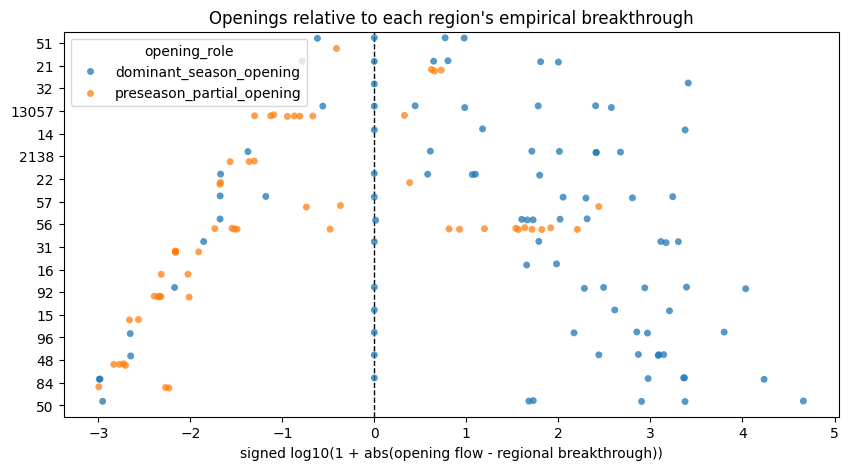

In [46]:
region_order = (
    region_breakthrough_thresholds.sort_values("breakthrough_raw_flow_threshold")["region"]
    .astype(str)
    .tolist()
)

plot_openings["region_cat"] = plot_openings["region"].astype(str)

fig, ax = plt.subplots(figsize=(10, max(5, 0.25 * len(region_order))))

sns.stripplot(
    data=plot_openings,
    x="raw_flow_minus_breakthrough_slog",
    y="region_cat",
    order=region_order,
    hue="opening_role",
    dodge=True,
    alpha=0.75,
    size=5,
    ax=ax,
)

ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("signed log10(1 + abs(opening flow - regional breakthrough))")
ax.set_ylabel("")
ax.set_title("Openings relative to each region's empirical breakthrough")
plt.show()

,region_cat,n_openings,threshold,threshold_method,breakthrough_n_openings,median_observed_flow,median_excess,synthetic_share,breakthrough_synthetic_event,threshold_log,median_excess_slog
10,50,6,2038.082551,nearest_p25,6,2464.018990,425.936439,0.166667,False,3.309435,2.630363
14,84,7,985.057292,nearest_p25,7,1262.393750,277.336458,0.285714,False,2.993902,2.444570
9,48,7,676.665625,nearest_p25,7,1414.886806,738.221181,0.428571,False,2.831015,2.868774
16,96,6,631.821875,nearest_p25,6,1060.260938,428.439063,0.500000,False,2.801281,2.632902
2,15,3,456.455417,min_fallback_n_lt_4,3,864.817692,408.362275,0.333333,False,2.660349,2.612108
15,92,7,366.833333,nearest_p25,7,675.977083,309.143750,0.428571,False,2.565651,2.491563
3,16,2,205.807292,min_fallback_n_lt_4,2,227.920052,22.112760,0.500000,True,2.315566,1.363852
7,31,6,143.657292,nearest_p25,6,822.026406,678.369115,0.500000,False,2.160340,2.832106
12,56,7,92.089583,nearest_p25,7,136.873611,44.784028,0.000000,False,1.968901,1.660714
13,57,7,57.101285,nearest_p25,7,168.558438,111.457153,0.428571,False,1.764186,2.050987


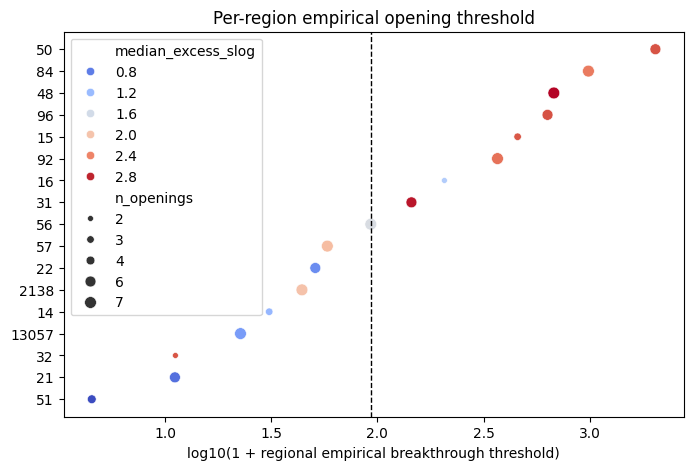

In [47]:
region_summary = (
    plot_df.groupby("region_cat", as_index=False)
    .agg(
        n_openings=("event_date", "size"),
        threshold=("breakthrough_raw_flow_threshold", "first"),
        threshold_method=("breakthrough_method", "first"),
        breakthrough_n_openings=("breakthrough_n_openings", "first"),
        median_observed_flow=(RAW_FLOW_COL, "median"),
        median_excess=("raw_flow_excess", "median"),
        synthetic_share=("synthetic_event", "mean"),
        breakthrough_synthetic_event=("breakthrough_synthetic_event", "first"),
    )
    .sort_values("threshold", ascending=False)
)

region_summary["threshold_log"] = log1p10(region_summary["threshold"])
region_summary["median_excess_slog"] = signed_log1p10(region_summary["median_excess"])

display(region_summary.head(30))

fig, ax = plt.subplots(figsize=(8, max(5, 0.25 * len(region_summary))))

sns.scatterplot(
    data=region_summary,
    x="threshold_log",
    y="region_cat",
    size="n_openings",
    hue="median_excess_slog",
    # style="threshold_method",
    palette="coolwarm",
    ax=ax,
)

ax.axvline(
    log1p10(region_summary["threshold"].median()),
    color="black",
    lw=1,
    ls="--",
)

ax.set_xlabel("log10(1 + regional empirical breakthrough threshold)")
ax.set_ylabel("")
ax.set_title("Per-region empirical opening threshold")
plt.show()

,region_cat,threshold,model_threshold,breakthrough_method,n_openings,breakthrough_event_date,breakthrough_event_water_year,breakthrough_synthetic_event,flow_days,mean_flow,median_flow,p75_flow,p90_flow,p95_flow,max_flow,threshold_log,mean_flow_log,median_flow_log,p90_flow_log,threshold_to_mean_ratio,threshold_to_p90_ratio
8,50,2038.082551,0.804668,nearest_p25,6,2020-04-14,2020,False,1805,2581.183472,263.630782,776.500000,6383.508333,12466.833333,102861.306818,3.309435,3.411987,2.422640,3.805127,0.789592,-0.495693
12,84,985.057292,0.532642,nearest_p25,7,2021-01-28,2021,False,2569,2736.752981,291.456250,1886.145833,8205.476250,14903.683333,56858.937500,2.993902,3.437394,2.466061,3.914157,0.359937,-0.920255
7,48,676.665625,0.689594,nearest_p25,7,2021-12-19,2022,False,2642,770.430861,111.214062,610.472396,2034.941042,3916.049132,17632.812500,2.831015,2.887297,2.050047,3.308765,0.878295,-0.477750
14,96,631.821875,0.346552,nearest_p25,6,2019-10-21,2020,False,2640,6070.573950,1935.807292,7532.372396,18518.822917,25342.385417,65586.250000,2.801281,3.783301,3.287086,4.267637,0.104079,-1.466355
1,15,456.455417,0.861157,min_fallback_n_lt_4,3,2019-01-26,2019,False,2581,398.247717,37.650729,149.236458,837.478125,1613.081250,15253.719444,2.660349,2.601242,1.587158,2.923492,1.146160,-0.263143
13,92,366.833333,0.251988,nearest_p25,7,2020-11-16,2021,False,2642,6834.262566,1611.312500,8556.890625,20071.854167,31132.898958,84552.569444,2.565651,3.834755,3.207449,4.302609,0.053676,-1.736958
2,16,205.807292,1.000000,min_fallback_n_lt_4,2,2023-03-22,2023,True,2089,2.542094,0.000000,0.000000,0.000750,0.184042,300.123333,2.315566,0.549260,0.000000,0.000326,80.959752,2.315240
5,31,143.657292,0.482203,nearest_p25,6,2019-01-19,2019,False,2515,979.579460,0.000000,103.873958,1485.326397,4707.625937,39509.791667,2.160340,2.991483,0.000000,3.172114,0.146652,-1.011774
10,56,92.089583,0.235417,nearest_p25,7,2019-10-29,2020,False,2646,949.235126,210.781250,620.945573,2337.246701,4911.921875,25186.840278,1.968901,2.977831,2.325888,3.368890,0.097015,-1.399989
11,57,57.101285,0.471711,nearest_p25,7,2018-11-25,2019,False,2645,305.935150,56.996354,181.965278,704.006458,1652.091667,8145.524306,1.764186,2.487047,1.763401,2.848193,0.186645,-1.084007


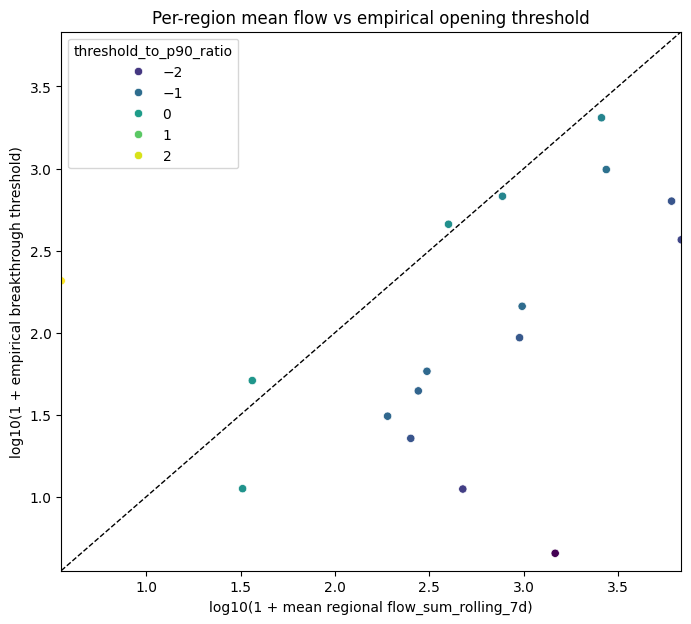

In [48]:
def log1p10(x):
    return np.log10(1 + np.maximum(x, 0))


flow_context = sim_all.copy()

if "model" in flow_context.columns and MODEL_NAME in set(flow_context["model"].dropna()):
    flow_context = flow_context[flow_context["model"].eq(MODEL_NAME)].copy()

flow_context = flow_context.dropna(subset=["region", RAW_FLOW_COL]).copy()
flow_context["region_cat"] = flow_context["region"].astype(str)

threshold_context = region_breakthrough_thresholds.dropna(
    subset=["region", "breakthrough_raw_flow_threshold"]
).copy()
threshold_context["region_cat"] = threshold_context["region"].astype(str)

region_flow_summary = flow_context.groupby("region_cat", as_index=False).agg(
    flow_days=(RAW_FLOW_COL, "size"),
    mean_flow=(RAW_FLOW_COL, "mean"),
    median_flow=(RAW_FLOW_COL, "median"),
    p75_flow=(RAW_FLOW_COL, lambda x: np.nanquantile(x, 0.75)),
    p90_flow=(RAW_FLOW_COL, lambda x: np.nanquantile(x, 0.90)),
    p95_flow=(RAW_FLOW_COL, lambda x: np.nanquantile(x, 0.95)),
    max_flow=(RAW_FLOW_COL, "max"),
)

region_threshold_summary = threshold_context[
    [
        "region_cat",
        "breakthrough_raw_flow_threshold",
        "breakthrough_model_flow_threshold",
        "breakthrough_method",
        "breakthrough_n_openings",
        "breakthrough_event_date",
        "breakthrough_event_water_year",
        "breakthrough_synthetic_event",
    ]
].rename(
    columns={
        "breakthrough_raw_flow_threshold": "threshold",
        "breakthrough_model_flow_threshold": "model_threshold",
        "breakthrough_n_openings": "n_openings",
    }
)

region_compare = region_threshold_summary.merge(
    region_flow_summary,
    on="region_cat",
    how="left",
)

region_compare["threshold_log"] = log1p10(region_compare["threshold"])
region_compare["mean_flow_log"] = log1p10(region_compare["mean_flow"])
region_compare["median_flow_log"] = log1p10(region_compare["median_flow"])
region_compare["p90_flow_log"] = log1p10(region_compare["p90_flow"])

region_compare["threshold_to_mean_ratio"] = (
    region_compare["threshold"] / region_compare["mean_flow"]
)
region_compare["threshold_to_p90_ratio"] = log1p10(region_compare["threshold"]) - log1p10(
    region_compare["p90_flow"]
)

display(region_compare.sort_values("threshold", ascending=False).head(30))


fig, ax = plt.subplots(figsize=(8, 7))

sns.scatterplot(
    data=region_compare,
    x="mean_flow_log",
    y="threshold_log",
    # size="n_openings",
    hue="threshold_to_p90_ratio",
    # style="breakthrough_method",
    palette="viridis",
    ax=ax,
)

lims = [
    np.nanmin([region_compare["mean_flow_log"].min(), region_compare["threshold_log"].min()]),
    np.nanmax([region_compare["mean_flow_log"].max(), region_compare["threshold_log"].max()]),
]

ax.plot(lims, lims, color="black", lw=1, ls="--")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(f"log10(1 + mean regional {RAW_FLOW_COL})")
ax.set_ylabel("log10(1 + empirical breakthrough threshold)")
ax.set_title("Per-region mean flow vs empirical opening threshold")
plt.show()

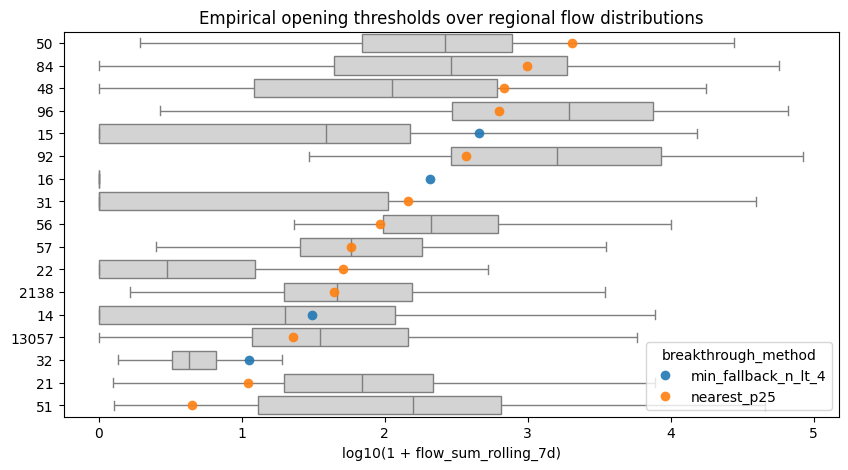

In [49]:
threshold_context = region_breakthrough_thresholds.dropna(
    subset=["region", "breakthrough_raw_flow_threshold"]
).copy()
threshold_context["region_cat"] = threshold_context["region"].astype(str)

region_order = threshold_context.sort_values("breakthrough_raw_flow_threshold", ascending=False)[
    "region_cat"
].tolist()

fig, ax = plt.subplots(figsize=(10, max(5, 0.25 * len(region_order))))

sns.boxplot(
    data=flow_context,
    x=log1p10(flow_context[RAW_FLOW_COL]),
    y="region_cat",
    order=region_order,
    color="lightgray",
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=threshold_context,
    x=log1p10(threshold_context["breakthrough_raw_flow_threshold"]),
    y="region_cat",
    order=region_order,
    hue="breakthrough_method",
    size=7,
    alpha=0.9,
    ax=ax,
)

ax.set_xlabel(f"log10(1 + {RAW_FLOW_COL})")
ax.set_ylabel("")
ax.set_title("Empirical opening thresholds over regional flow distributions")
plt.show()

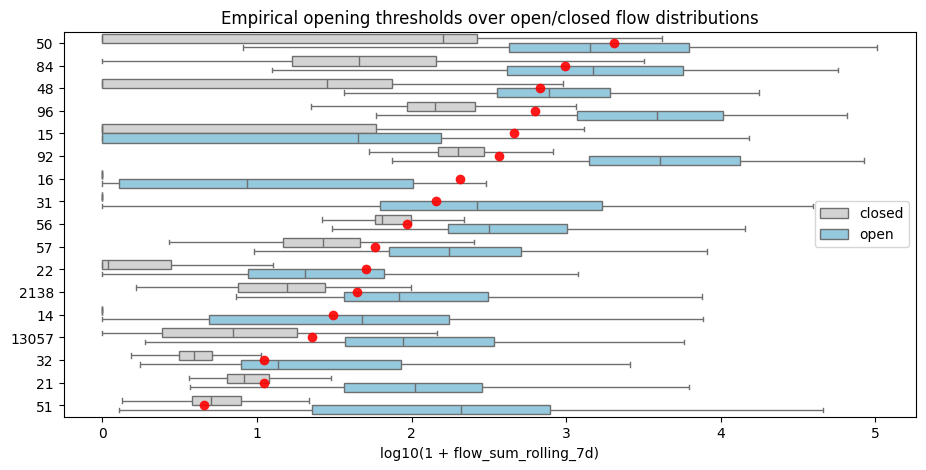

In [60]:
flow_context_state = flow_context.copy()

# Pick the state definition you trust most.
# For model-specific simulated state, y_pred_open is usually the cleanest.
if "y_pred_open" in flow_context_state.columns:
    flow_context_state["flow_state"] = np.where(
        flow_context_state["y_pred_open"].astype(float).ge(0.5),
        "open",
        "closed",
    )
elif "p_open" in flow_context_state.columns:
    flow_context_state["flow_state"] = np.where(
        flow_context_state["p_open"].astype(float).ge(0.5),
        "open",
        "closed",
    )
else:
    flow_context_state["flow_state"] = flow_context_state["prev_state"]

flow_context_state = flow_context_state.dropna(
    subset=["region_cat", RAW_FLOW_COL, "flow_state"]
).copy()

flow_context_state["flow_log"] = log1p10(flow_context_state[RAW_FLOW_COL])

threshold_context = region_breakthrough_thresholds.dropna(
    subset=["region", "breakthrough_raw_flow_threshold"]
).copy()
threshold_context["region_cat"] = threshold_context["region"].astype(str)
threshold_context["threshold_log"] = log1p10(threshold_context["breakthrough_raw_flow_threshold"])

region_order = threshold_context.sort_values("breakthrough_raw_flow_threshold", ascending=False)[
    "region_cat"
].tolist()

fig, ax = plt.subplots(figsize=(11, max(5, 0.28 * len(region_order))))

sns.boxplot(
    data=flow_context_state,
    x="flow_log",
    y="region_cat",
    hue="flow_state",
    order=region_order,
    hue_order=["closed", "open"],
    showfliers=False,
    dodge=True,
    palette={"closed": "lightgray", "open": "skyblue"},
    ax=ax,
)

sns.stripplot(
    data=threshold_context,
    x="threshold_log",
    y="region_cat",
    order=region_order,
    color="red",
    size=7,
    alpha=0.9,
    ax=ax,
)

ax.set_xlabel(f"log10(1 + {RAW_FLOW_COL})")
ax.set_ylabel("")
ax.set_title("Empirical opening thresholds over open/closed flow distributions")
plt.savefig("/Users/kyledorman/Desktop/opening_threshold_vs_open_closed_dist.png")
plt.show()

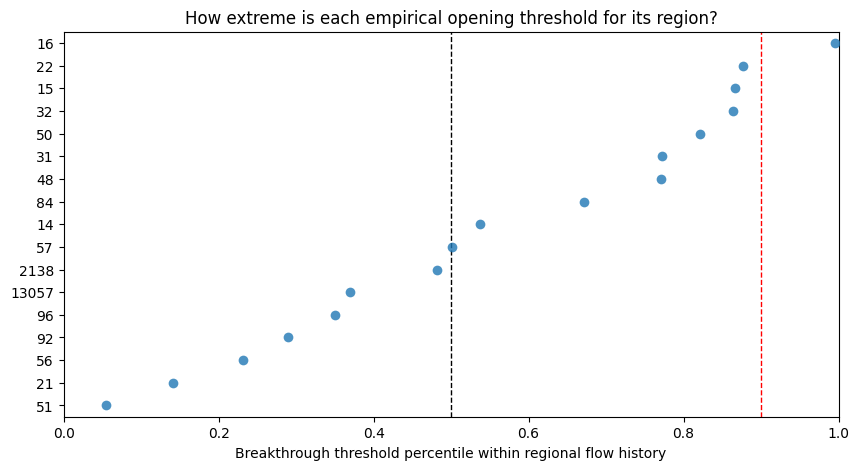

In [58]:
def percentile_in_region_flow(row, flow_lookup):
    vals = flow_lookup.get(row["region_cat"])

    if vals is None or len(vals) == 0 or pd.isna(row["breakthrough_raw_flow_threshold"]):
        return np.nan

    return np.mean(vals <= row["breakthrough_raw_flow_threshold"])


flow_lookup = {
    region: g[RAW_FLOW_COL].dropna().to_numpy() for region, g in flow_context.groupby("region_cat")
}

threshold_context = region_breakthrough_thresholds.dropna(
    subset=["region", "breakthrough_raw_flow_threshold"]
).copy()
threshold_context["region_cat"] = threshold_context["region"].astype(str)

threshold_context["threshold_flow_percentile"] = threshold_context.apply(
    percentile_in_region_flow,
    axis=1,
    flow_lookup=flow_lookup,
)

region_order = threshold_context.sort_values("threshold_flow_percentile", ascending=False)[
    "region_cat"
].tolist()

fig, ax = plt.subplots(figsize=(10, max(5, 0.25 * threshold_context["region_cat"].nunique())))

sns.stripplot(
    data=threshold_context,
    x="threshold_flow_percentile",
    y="region_cat",
    order=region_order,
    # hue="breakthrough_method",
    alpha=0.8,
    size=7,
    ax=ax,
)

ax.axvline(0.5, color="black", lw=1, ls="--")
ax.axvline(0.9, color="red", lw=1, ls="--")
ax.set_xlim(0, 1)
ax.set_xlabel("Breakthrough threshold percentile within regional flow history")
ax.set_ylabel("")
ax.set_title("How extreme is each empirical opening threshold for its region?")
plt.show()

In [51]:
open_context = sim_all.copy()

if "model" in open_context.columns and MODEL_NAME in set(open_context["model"].dropna()):
    open_context = open_context[open_context["model"].eq(MODEL_NAME)].copy()

open_context["region_cat"] = open_context["region"].astype(str)

# Pick one definition of open.
# y_pred_open is binary-ish if available; p_open >= 0.5 is the fallback.
if "y_pred_open" in open_context.columns:
    open_context["is_open_for_pct"] = open_context["y_pred_open"].astype(float)
else:
    open_context["is_open_for_pct"] = open_context["p_open"].ge(0.5).astype(float)

region_open_summary = (
    open_context.dropna(subset=["region_cat", "is_open_for_pct"])
    .groupby("region_cat", as_index=False)
    .agg(
        percent_time_open=("is_open_for_pct", "mean"),
        mean_p_open=("p_open", "mean"),
        n_days=("date", "size"),
    )
)

region_open_summary["percent_time_open"] *= 100

display(region_open_summary.sort_values("percent_time_open"))

,region_cat,percent_time_open,mean_p_open,n_days
3,16,3.781714,0.035587,2089
8,32,16.150740,0.153101,2229
9,33,21.384929,0.205069,982
7,31,37.216700,0.368558,2515
6,22,38.374806,0.370727,2572
11,50,40.609418,0.403887,1805
10,48,41.786525,0.412865,2642
14,57,50.170132,0.494270,2645
15,84,54.690541,0.539435,2569
0,13057,63.076342,0.619864,2646


In [62]:
threshold_context = region_breakthrough_thresholds.dropna(
    subset=["region", "breakthrough_raw_flow_threshold"]
).copy()
threshold_context["region_cat"] = threshold_context["region"].astype(str)

threshold_context["threshold_flow_percentile"] = threshold_context.apply(
    percentile_in_region_flow,
    axis=1,
    flow_lookup=flow_lookup,
)

threshold_context = threshold_context.merge(
    region_open_summary,
    on="region_cat",
    how="left",
)

display(
    threshold_context[
        [
            "region_cat",
            "breakthrough_event_water_year",
            "breakthrough_event_date",
            "breakthrough_raw_flow_threshold",
            "threshold_flow_percentile",
            "percent_time_open",
            "breakthrough_synthetic_event",
            "breakthrough_method",
            "breakthrough_n_openings",
        ]
    ].sort_values(["percent_time_open", "region_cat"])
)

,region_cat,breakthrough_event_water_year,breakthrough_event_date,breakthrough_raw_flow_threshold,threshold_flow_percentile,percent_time_open,breakthrough_synthetic_event,breakthrough_method,breakthrough_n_openings
2,16,2023,2023-03-22,205.807292,0.995213,3.781714,True,min_fallback_n_lt_4,2
6,32,2024,2023-12-30,10.185521,0.863616,16.150740,False,min_fallback_n_lt_4,2
5,31,2019,2019-01-19,143.657292,0.771769,37.216700,False,nearest_p25,6
4,22,2019,2019-01-10,49.998734,0.876361,38.374806,True,nearest_p25,6
8,50,2020,2020-04-14,2038.082551,0.821607,40.609418,False,nearest_p25,6
7,48,2022,2021-12-19,676.665625,0.771007,41.786525,False,nearest_p25,7
11,57,2019,2018-11-25,57.101285,0.501701,50.170132,False,nearest_p25,7
12,84,2021,2021-01-28,985.057292,0.671078,54.690541,False,nearest_p25,7
16,13057,2024,2023-11-11,21.653958,0.369992,63.076342,False,nearest_p25,7
15,2138,2024,2023-11-26,43.115521,0.482224,67.511346,False,nearest_p25,7


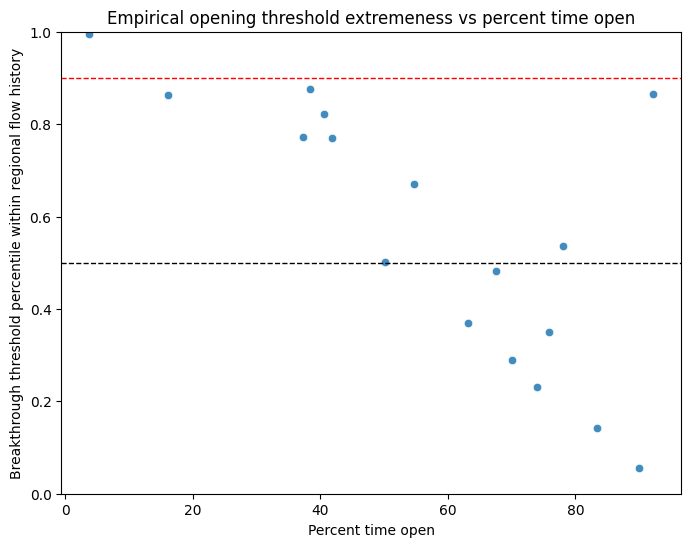

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=threshold_context,
    x="percent_time_open",
    y="threshold_flow_percentile",
    # hue="breakthrough_synthetic_event",
    # style="breakthrough_method",
    # size="breakthrough_raw_flow_threshold",
    alpha=0.85,
    ax=ax,
)

ax.axhline(0.5, color="black", lw=1, ls="--")
ax.axhline(0.9, color="red", lw=1, ls="--")
ax.set_ylim(0, 1)
ax.set_xlabel("Percent time open")
ax.set_ylabel("Breakthrough threshold percentile within regional flow history")
ax.set_title("Empirical opening threshold extremeness vs percent time open")
plt.show()

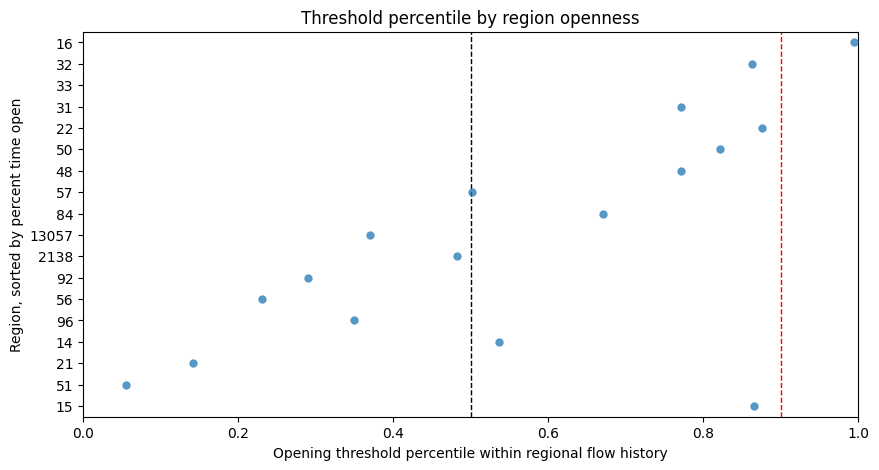

In [65]:
region_order_by_open = region_open_summary.sort_values("percent_time_open")["region_cat"].tolist()

fig, ax = plt.subplots(figsize=(10, max(5, 0.25 * len(region_order_by_open))))

sns.stripplot(
    data=threshold_context,
    x="threshold_flow_percentile",
    y="region_cat",
    order=region_order_by_open,
    dodge=True,
    alpha=0.75,
    size=6,
    ax=ax,
)

ax.axvline(0.5, color="black", lw=1, ls="--")
ax.axvline(0.9, color="red", lw=1, ls="--")
ax.set_xlim(0, 1)
ax.set_xlabel("Opening threshold percentile within regional flow history")
ax.set_ylabel("Region, sorted by percent time open")
ax.set_title("Threshold percentile by region openness")
plt.savefig("/Users/kyledorman/Desktop/threshold_vs_p_open.png")
plt.show()

In [87]:
raw_flow_candidates = [
    "streamflow_mean",
    "streamflow_median",
    "streamflow_p90",
    "streamflow_max",
    "flow_n_obs",
]
display(sim_all[raw_flow_candidates].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(1).T)
RAW_FLOW_COL = "streamflow_p90"  # or "streamflow_mean"

first_opening_drivers = attach_max_flow_driver_rows(
    first_openings,
    sim,
    flow_col=RAW_FLOW_COL,
)

valid_dominant = first_opening_drivers.dropna(subset=["region", RAW_FLOW_COL]).copy()

raw_threshold_table = (
    region_breakthrough_thresholds.merge(
        region_open_summary[["region_cat", "percent_time_open"]],
        left_on=region_breakthrough_thresholds["region"].astype(str),
        right_on="region_cat",
        how="left",
    )
    .drop(columns=["key_0"], errors="ignore")
    .sort_values("breakthrough_raw_flow_threshold")
)

gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf["region"] = gdf["Site code"]
gdf = gdf.set_index("region")
gdf = gdf.rename(columns={"Estuary_Name": "estuary"})

raw_threshold_table = raw_threshold_table.merge(
    gdf[["estuary"]], left_on="region", right_index=True
)

display(
    raw_threshold_table[
        [
            "estuary",
            "breakthrough_raw_flow_threshold",
            # "breakthrough_method",
            # "breakthrough_n_openings",
            # "breakthrough_event_water_year",
            # "breakthrough_driver_selected_date",
            "percent_time_open",
            # "breakthrough_synthetic_event",
            # "breakthrough_obs_gap_days",
        ]
    ].round(1)
)

# raw_threshold_table = raw_threshold_table.rename(
#     columns={
#         "breakthrough_raw_flow_threshold": f"empirical_opening_threshold_{RAW_FLOW_COL}",
#         "breakthrough_method": "threshold_method",
#         "breakthrough_n_openings": "n_dominant_openings_used",
#         "breakthrough_event_water_year": "example_water_year",
#         "breakthrough_driver_selected_date": "max_flow_date_in_opening_window",
#         "percent_time_open": "percent_time_open",
#         "breakthrough_synthetic_event": "gap_filled_opening",
#         "breakthrough_obs_gap_days": "opening_obs_gap_days",
#     }
# )

# display(raw_threshold_table.round(1))

,count,mean,std,min,25%,50%,75%,90%,95%,max
streamflow_mean,303310.0,208.0,868.7,0.0,0.5,8.7,54.0,357.9,1068.2,27555.2
streamflow_median,303310.0,202.3,852.7,0.0,0.5,8.6,53.0,346.8,1029.5,26437.5
streamflow_p90,303310.0,254.0,1148.4,0.0,0.5,9.3,57.6,404.6,1256.0,41405.0
streamflow_max,303310.0,269.8,1228.9,0.0,0.6,9.5,59.4,428.2,1332.5,42575.0
flow_n_obs,303310.0,24.0,0.4,15.0,24.0,24.0,24.0,24.0,24.0,24.0


,estuary,breakthrough_raw_flow_threshold,percent_time_open
9,Pajaro River,3.5,90.0
3,Ventura River,10.1,83.3
6,San Antonio Creek,10.2,16.2
16,San Gregorio Creek,21.7,63.1
0,San Luis Rey River,29.9,78.0
15,Pescadero Creek,43.1,67.5
4,Carpinteria Creek,50.0,38.4
11,Soquel Creek,57.1,50.2
10,San Lorenzo River,92.1,74.0
5,Santa Ynez River,143.7,37.2


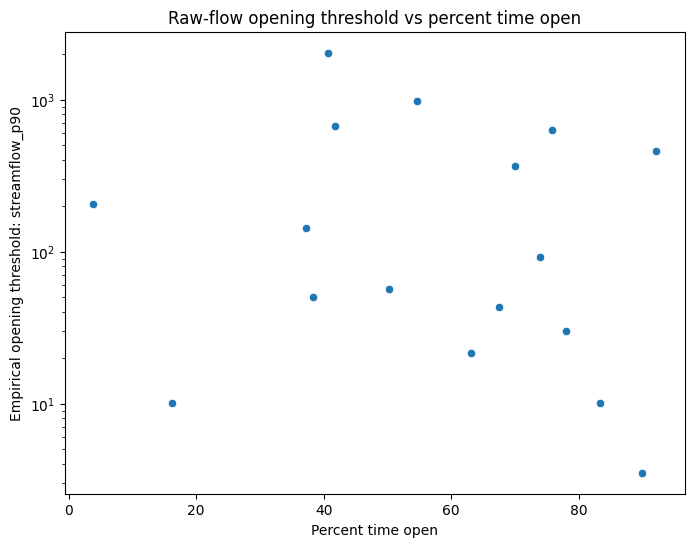

In [89]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=raw_threshold_table,
    x="percent_time_open",
    y="breakthrough_raw_flow_threshold",
    # hue="threshold_method",
    # size="n_dominant_openings_used",
    ax=ax,
)

ax.set_yscale("log")
ax.set_xlabel("Percent time open")
ax.set_ylabel(f"Empirical opening threshold: {RAW_FLOW_COL}")
ax.set_title("Raw-flow opening threshold vs percent time open")
plt.savefig("/Users/kyledorman/Desktop/raw_threshold_vs_p_open.png")
plt.show()